## 1. Import Dependencies

In [2]:
import os
import time
import copy
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import WeightedRandomSampler
import torch.onnx

import sys
sys.path.append("..")
from config import Config

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.0.1+cu118
CUDA available  : True
GPU             : NVIDIA GeForce GTX 1050


## 3. Load Data
Load image paths and labels, then compute the **class weight** to correct the imbalance between Normal and Pneumonia samples.


In [3]:
## 3. Load Data
def load_data(data_dir: str):
    train_normal    = glob.glob(f"{data_dir}/train/NORMAL/*")
    train_pneumonia = glob.glob(f"{data_dir}/train/PNEUMONIA/*")
    test_normal     = glob.glob(f"{data_dir}/test/NORMAL/*")
    test_pneumonia  = glob.glob(f"{data_dir}/test/PNEUMONIA/*")

    train_paths  = train_normal + train_pneumonia
    test_paths   = test_normal  + test_pneumonia
    train_labels = [0] * len(train_normal)  + [1] * len(train_pneumonia)
    test_labels  = [0] * len(test_normal)   + [1] * len(test_pneumonia)

    print(f"Train — Normal: {len(train_normal):,} | Pneumonia: {len(train_pneumonia):,}")
    print(f"Test  — Normal: {len(test_normal):,}  | Pneumonia: {len(test_pneumonia):,}")

    return train_paths, test_paths, train_labels, test_labels


train_paths, test_paths, train_labels, test_labels = load_data(Config.DATA_DIR)

# stratified split to keep class ratio in validation set
train_paths, valid_paths, train_labels, valid_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=Config.SEED,
)
print(f"\nTrain size : {len(train_paths):,}")
print(f"Val size   : {len(valid_paths):,}")
print(f"Test size  : {len(test_paths):,}")

Train — Normal: 1,341 | Pneumonia: 3,875
Test  — Normal: 234  | Pneumonia: 390

Train size : 4,172
Val size   : 1,044
Test size  : 624


## 4. Visualise Sample Images

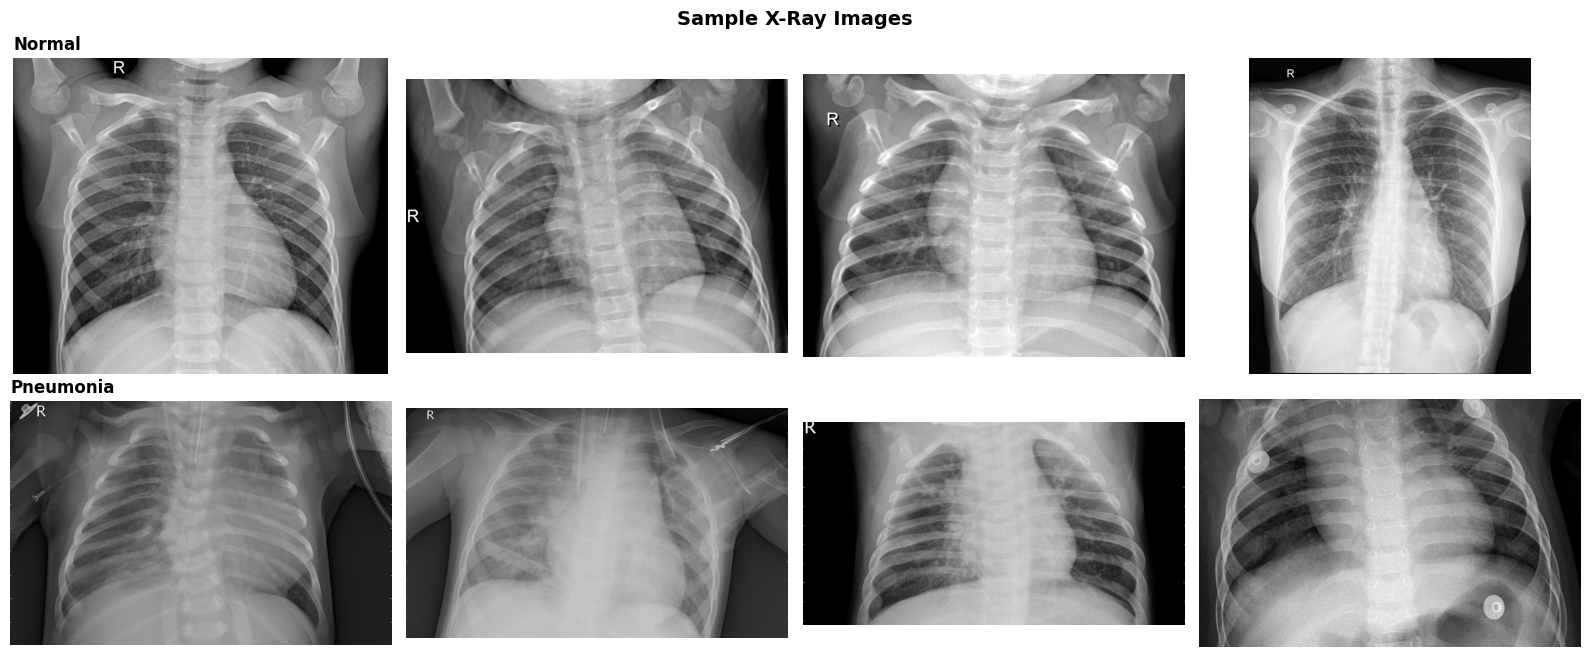

In [4]:
def show_random_samples(paths: list, labels: list, n: int = 4):
    """Show n random samples from each class side by side."""
    normal_paths    = [p for p, l in zip(paths, labels) if l == 0]
    pneumonia_paths = [p for p, l in zip(paths, labels) if l == 1]

    fig, axes = plt.subplots(2, n, figsize=(16, 7))
    fig.suptitle("Sample X-Ray Images", fontsize=14, fontweight="bold")

    for i in range(n):
        for row, (class_paths, title) in enumerate(
            [(normal_paths, "Normal"), (pneumonia_paths, "Pneumonia")]
        ):
            img = Image.open(random.choice(class_paths)).convert("L")
            axes[row, i].imshow(img, cmap="gray")
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].set_title(title, fontsize=12, fontweight="bold", loc="left")

    plt.tight_layout()
    plt.show()


show_random_samples(train_paths, train_labels)

## 5. Dataset & Transforms

**Train transforms** include augmentation (flip, rotation, colour jitter) to improve generalisation.  
**Validation / Test transforms** only resize and normalise — never augment evaluation data.

ImageNet mean and std are used because ResNet was pretrained on ImageNet.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class XRayDataset(Dataset):
    """Custom PyTorch Dataset for chest X-ray images."""

    def __init__(self, paths: list, labels: list, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        image = Image.open(self.paths[index]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor([self.labels[index]], dtype=torch.float32)
        return image, label

# ── Sampler ───────────────────────────────────────────────────────────────────
# assign a weight to each sample — minority class gets higher weight
class_counts  = [train_labels.count(0), train_labels.count(1)]  # [normal, pneumonia]
class_weights = [1.0 / c for c in class_counts]                  # inverse frequency
sample_weights = [class_weights[label] for label in train_labels] # per-sample weight

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
)

print(f"Class counts  — Normal: {class_counts[0]:,} | Pneumonia: {class_counts[1]:,}")
print(f"Class weights — Normal: {class_weights[0]:.6f} | Pneumonia: {class_weights[1]:.6f}")


# build datasets
datasets = {
    "train": XRayDataset(train_paths, train_labels, train_transforms),
    "val":   XRayDataset(valid_paths, valid_labels, test_transforms),
}

# build dataloaders
dataloaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size  = Config.BATCH_SIZE,
        sampler     = sampler,          # replaces shuffle=True
        num_workers = Config.NUM_WORKERS,
    ),
    "val": DataLoader(
        datasets["val"],
        batch_size  = Config.BATCH_SIZE,
        shuffle     = False,
        num_workers = Config.NUM_WORKERS,
    ),
}

dataset_sizes = {phase: len(ds) for phase, ds in datasets.items()}
print(f"Train batches : {len(dataloaders['train'])}")
print(f"Val batches   : {len(dataloaders['val'])}")

Class counts  — Normal: 1,073 | Pneumonia: 3,099
Class weights — Normal: 0.000932 | Pneumonia: 0.000323
Train batches : 131
Val batches   : 33


## 6. Model — ResNet18 Transfer Learning

We load ResNet18 pretrained on ImageNet and replace only the final fully-connected layer:
- **Keep:** all convolutional layers with learned ImageNet features
- **Replace:** `fc` layer → `Linear(512, 1)` for binary output


In [6]:
class PneumoniaNet(nn.Module):
    """ResNet18 with custom binary classification head."""
    def __init__(self, pretrained: bool = True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None   # load ImageNet weights. Otherwise start from scratch.
        self.backbone = resnet18(weights=weights)                    # This loads the full ResNet18 architecture and fit it with the weights
        self.backbone.fc = nn.Linear(512, 1)                         # replace final layer: ImageNet 1000 classes → binary output

    def forward(self, x):
        return self.backbone(x)


model = PneumoniaNet(pretrained=True).to(Config.DEVICE)

# quick sanity check — confirm output shape
dummy = torch.randn(2, 3, 224, 224).to(Config.DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape  : {dummy.shape}")
print(f"Output shape : {out.shape}  ← (batch_size, 1) ✅")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\yousef/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:35<00:00, 1.32MB/s]


Input shape  : torch.Size([2, 3, 224, 224])
Output shape : torch.Size([2, 1])  ← (batch_size, 1) ✅

Total params     : 11,177,025
Trainable params : 11,177,025


## 7. Training Loop

Key features:
- **`WeightedRandomSampler`** corrects class imbalance at the data level
- **`ReduceLROnPlateau`** halves the LR when val loss plateaus
- **Early stopping** stops training if val loss doesn't improve for `patience` epochs
- **Best model** saved based on lowest val loss


In [7]:
def train_model(
    model, criterion, optimizer, scheduler,
    dataloaders: dict, dataset_sizes: dict,
    num_epochs: int, device: str, patience: int
):
    since          = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss  = float("inf")
    early_stop_ctr = 0
    history        = {"train_loss": [], "val_loss": [],
                      "train_acc":  [], "val_acc":  []}

    os.makedirs("models", exist_ok=True)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}  {'─' * 35}")

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss     = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase],
                                       desc=f"  {phase:5s}",
                                       leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.sigmoid() > 0.5

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.bool())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"  {phase:5s} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

            if phase == "val":
                scheduler.step(epoch_loss)

                if epoch_loss < best_val_loss:
                    best_val_loss  = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), "models/resnet18_best.pth")
                    print(f"  ✅ Best model saved — Val Loss: {best_val_loss:.4f}")
                    early_stop_ctr = 0
                else:
                    early_stop_ctr += 1
                    print(f"  ⚠️  No improvement ({early_stop_ctr}/{patience})")

                if early_stop_ctr >= patience:
                    print("\n⛔ Early stopping triggered!")
                    model.load_state_dict(best_model_wts)
                    elapsed = time.time() - since
                    print(f"Training stopped at epoch {epoch + 1}")
                    print(f"Total time : {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
                    return model, history

    model.load_state_dict(best_model_wts)
    elapsed = time.time() - since
    print(f"\nTraining complete — {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"Best val loss : {best_val_loss:.4f}")
    return model, history

In [8]:
# initialise training components
criterion = nn.BCEWithLogitsLoss()   
optimizer = Adam(model.parameters(), lr=Config.LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min",
                              patience=3, factor=0.5, verbose=True)

# run training
model, history = train_model(
    model, criterion, optimizer, scheduler,
    dataloaders, dataset_sizes,
    num_epochs=Config.NUM_EPOCHS,
    device=Config.DEVICE,
    patience=Config.PATIENCE,
)


Epoch 1/15  ───────────────────────────────────


  train — Loss: 0.1336  Acc: 0.9516


  val   — Loss: 0.0555  Acc: 0.9837
  ✅ Best model saved — Val Loss: 0.0555

Epoch 2/15  ───────────────────────────────────


  train — Loss: 0.0683  Acc: 0.9744


  val   — Loss: 0.0468  Acc: 0.9818
  ✅ Best model saved — Val Loss: 0.0468

Epoch 3/15  ───────────────────────────────────


...

  val   — Loss: 0.0318  Acc: 0.9895
  ⚠️  No improvement (1/3)

Epoch 8/15  ───────────────────────────────────


  train — Loss: 0.0176  Acc: 0.9952


  val   — Loss: 0.0319  Acc: 0.9875
  ⚠️  No improvement (2/3)

Epoch 9/15  ───────────────────────────────────


  train — Loss: 0.0233  Acc: 0.9921


  val   — Loss: 0.0327  Acc: 0.9885
  ⚠️  No improvement (3/3)

⛔ Early stopping triggered!
Training stopped at epoch 9
Total time : 50m 18s


## 8. Training Curves

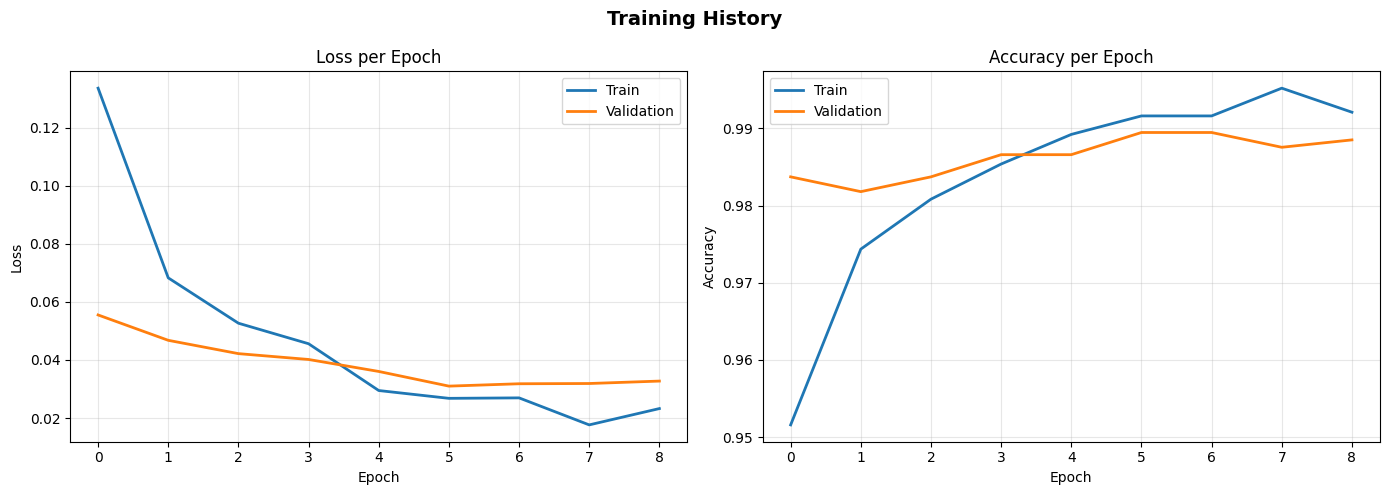

In [9]:
def plot_training_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")

    for ax, metric, title, ylabel in zip(
        axes,
        [("train_loss", "val_loss"), ("train_acc", "val_acc")],
        ["Loss per Epoch", "Accuracy per Epoch"],
        ["Loss", "Accuracy"],
    ):
        ax.plot(history[metric[0]], label="Train", linewidth=2)
        ax.plot(history[metric[1]], label="Validation", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## 9. Evaluation on Test Set

Metrics:
- **Accuracy** — overall correct predictions
- **F1 Score** — balance between precision and recall (important for imbalanced data)
- **Classification Report** — per-class breakdown
- **Confusion Matrix** — visual of correct vs wrong predictions per class


Accuracy : 0.8013
F1 Score : 0.8628

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.47      0.64       234
   Pneumonia       0.76      1.00      0.86       390

    accuracy                           0.80       624
   macro avg       0.88      0.74      0.75       624
weighted avg       0.85      0.80      0.78       624



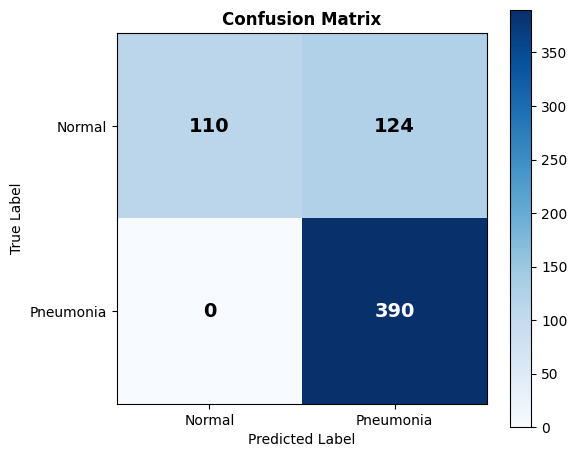

In [10]:
def plot_confusion_matrix(all_labels: np.ndarray, all_preds: np.ndarray):
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title("Confusion Matrix", fontweight="bold")
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Pneumonia"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Pneumonia"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


def evaluate_model(model, dataloader, device: str):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            outputs = model(inputs.to(device))
            preds   = outputs.sigmoid() > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    print(f"Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
    print(f"F1 Score : {f1_score(all_labels, all_preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=["Normal", "Pneumonia"]))
    plot_confusion_matrix(all_labels, all_preds)


test_dataset    = XRayDataset(test_paths, test_labels, test_transforms)
test_dataloader = DataLoader(test_dataset,
                             batch_size=Config.BATCH_SIZE,
                             num_workers=Config.NUM_WORKERS)

evaluate_model(model, test_dataloader, Config.DEVICE)

## 10. Save Final Model

In [11]:
os.makedirs("models", exist_ok=True)

dummy_input = torch.randn(1, 3, 224, 224).to(Config.DEVICE)  # RGB, 3 channels

torch.onnx.export(
    model,
    dummy_input,
    "../models/model_v3_resnet18.onnx",  
    input_names   = ["input"],
    output_names  = ["output"],
    dynamic_axes  = {"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    opset_version = 17,
)

print("✅ Model exported to ../models/model_v3_resnet18.onnx")

============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

✅ Model exported to ../models/model_v3_resnet18.onnx
